# 6장 실습 — 2차 뉴런 모델 (시냅스·알파)

**Spiking Neural Networks 쿡북 with Python** · 6장 실습 노트북

입력이 막전위에 즉시 반영되는 1차 LIF를 넘어, **시냅스 전류**라는 중간 상태를 둔 2차 뉴런을 실험한다. `snn.Synaptic`, `snn.Alpha`를 시뮬레이션하고 1차 뉴런과 반응을 비교한다.

### 학습 목표
- `snn.Synaptic`의 시냅스 전류·막전위 두 상태를 관찰한다.
- `snn.Alpha`의 매끄러운 막전위 반응을 본다.
- 1차(`snn.Leaky`) vs 2차(`snn.Synaptic`) 반응을 비교한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. 시냅스 전도 기반 2차 뉴런 — `snn.Synaptic`

`snn.Synaptic`은 상태가 두 개다: 시냅스 전류 `syn`(감쇠율 `alpha`)과 막전위 `mem`(감쇠율 `beta`). 주기적인 입력 스파이크를 주고, 입력 → 시냅스 전류 → 막전위 → 출력으로 신호가 번지는 과정을 본다.

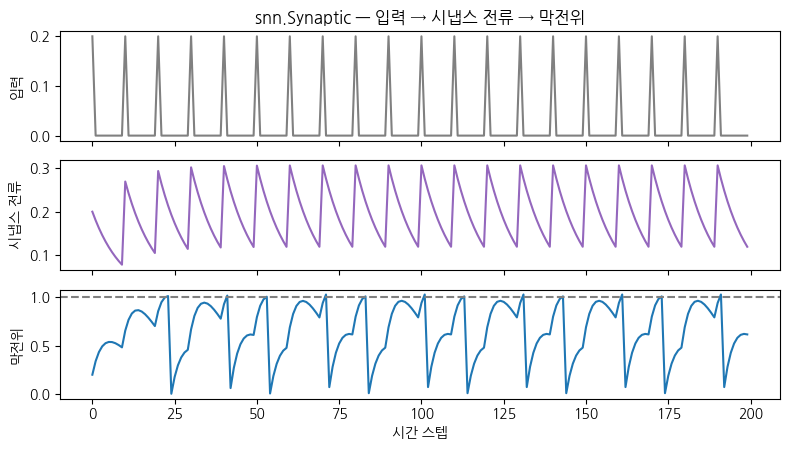

In [2]:
lif = snn.Synaptic(alpha=0.9, beta=0.8)    # 2차 뉴런 (상태 2개)

num_steps = 200
# 10스텝마다 한 번 발화하는 주기적 입력
spk_period = torch.cat([torch.ones(1) * 0.2, torch.zeros(9)])
spk_in = spk_period.repeat(20).unsqueeze(1)        # (200, 1)

syn, mem = lif.init_synaptic()      # 시냅스 전류·막전위 초기화
syn_rec, mem_rec, spk_rec = [], [], []

for step in range(num_steps):
    spk, syn, mem = lif(spk_in[step], syn, mem)   # 상태 2개를 함께 갱신
    syn_rec.append(syn)
    mem_rec.append(mem)
    spk_rec.append(spk)

syn_rec = torch.stack(syn_rec).squeeze().detach().numpy()
mem_rec = torch.stack(mem_rec).squeeze().detach().numpy()

fig, (a0, a1, a2) = plt.subplots(3, 1, figsize=(8, 4.6), sharex=True)
a0.plot(spk_in.squeeze().numpy(), color='gray'); a0.set_ylabel('입력')
a0.set_title('snn.Synaptic — 입력 → 시냅스 전류 → 막전위')
a1.plot(syn_rec, color='tab:purple'); a1.set_ylabel('시냅스 전류')
a2.plot(mem_rec, color='tab:blue'); a2.axhline(1.0, color='gray', linestyle='--')
a2.set_ylabel('막전위'); a2.set_xlabel('시간 스텝')
plt.tight_layout(); plt.show()

## 3. 알파 뉴런 — `snn.Alpha`

`snn.Alpha`는 막전위 반응이 **빠르게 올랐다 천천히 내려가는** 매끄러운 알파 함수 모양을 갖는다. 흥분·억제 두 전류 상태를 함께 관리한다. 한 번의 입력에 막전위가 어떻게 반응하는지 본다.

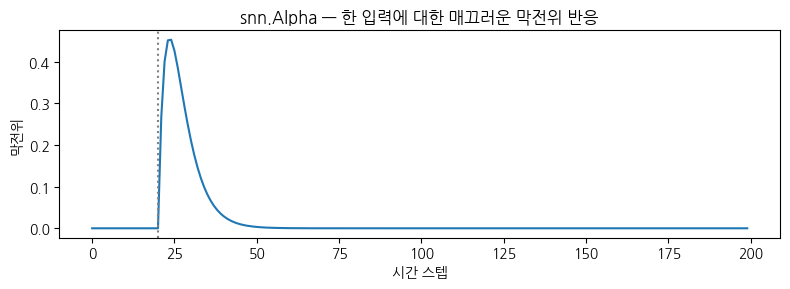

In [3]:
lif = snn.Alpha(alpha=0.8, beta=0.7, threshold=0.5)   # 알파 뉴런

num_steps = 200
# 한 번의 입력 스파이크
spk_in = torch.zeros(num_steps, 1)
spk_in[20] = 1.0

syn_exc, syn_inh, mem = lif.init_alpha()   # 흥분·억제 전류, 막전위 초기화
mem_rec = []

for step in range(num_steps):
    spk, syn_exc, syn_inh, mem = lif(spk_in[step], syn_exc, syn_inh, mem)
    mem_rec.append(mem)

mem_rec = torch.stack(mem_rec).squeeze().detach().numpy()

plt.figure(figsize=(8, 3))
plt.plot(mem_rec, color='tab:blue')
plt.axvline(20, color='gray', linestyle=':')
plt.xlabel('시간 스텝'); plt.ylabel('막전위')
plt.title('snn.Alpha — 한 입력에 대한 매끄러운 막전위 반응')
plt.tight_layout(); plt.show()

## 4. 1차 vs 2차 뉴런 반응 비교

같은 단일 입력 스파이크를 1차(`snn.Leaky`)와 2차(`snn.Synaptic`)에 주고 막전위 반응을 겹쳐 그린다. 1차는 입력 순간 **즉시 점프**하고, 2차는 시냅스 전류를 거쳐 **부드럽게** 차올랐다 내려간다.

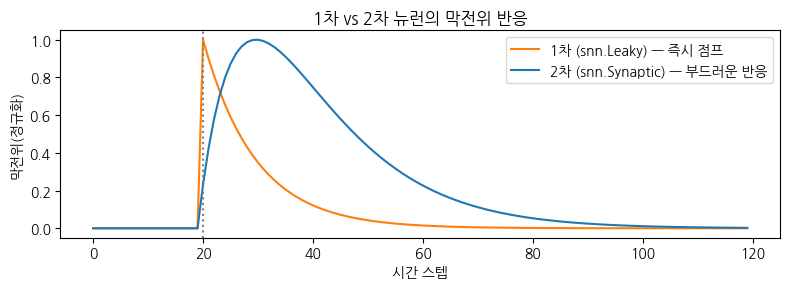

In [4]:
num_steps = 120
spk_in = torch.zeros(num_steps, 1)
spk_in[20] = 1.0

# 1차 뉴런 (snn.Leaky)
leaky = snn.Leaky(beta=0.9, threshold=99)   # 임계값을 크게 두어 발화 없이 반응만 관찰
mem = leaky.init_leaky()
mem1 = []
for step in range(num_steps):
    spk, mem = leaky(spk_in[step], mem)
    mem1.append(mem)
mem1 = torch.stack(mem1).squeeze().detach().numpy()

# 2차 뉴런 (snn.Synaptic)
synaptic = snn.Synaptic(alpha=0.92, beta=0.9, threshold=99)
syn, mem = synaptic.init_synaptic()
mem2 = []
for step in range(num_steps):
    spk, syn, mem = synaptic(spk_in[step], syn, mem)
    mem2.append(mem)
mem2 = torch.stack(mem2).squeeze().detach().numpy()

plt.figure(figsize=(8, 3))
plt.plot(mem1 / mem1.max(), label='1차 (snn.Leaky) — 즉시 점프', color='tab:orange')
plt.plot(mem2 / mem2.max(), label='2차 (snn.Synaptic) — 부드러운 반응', color='tab:blue')
plt.axvline(20, color='gray', linestyle=':')
plt.xlabel('시간 스텝'); plt.ylabel('막전위(정규화)')
plt.title('1차 vs 2차 뉴런의 막전위 반응')
plt.legend()
plt.tight_layout(); plt.show()

## 정리

- `snn.Synaptic`은 시냅스 전류(`alpha`)와 막전위(`beta`) 두 상태로 입력을 시간에 번지게 한다.
- `snn.Alpha`는 두 지수의 차로 매끄러운 막전위 반응을 만든다.
- 1차 뉴런은 즉시 점프, 2차 뉴런은 부드러운 반응 — 시간 표현력과 연산량의 트레이드오프다.

이로써 2부를 마친다. 3부에서는 이 네트워크를 대리 경사와 BPTT로 학습시킨다.